# 1. Download Gaze Fraction Sweeps 
This cell connects to W&B to fetch the data from the two new sweeps:
* `y1z4uig3`: Align mode (Raw and Rollout)
* `erzza4rm`: EGViT, Guide (GII Injection), and Disable (Off)

It extracts the `train_gaze_frac` parameter, as well as the test accuracy achieved at the best validation epoch.

In [1]:
import wandb
import pandas as pd
import numpy as np

# ==========================================
# CONFIGURATION
# ==========================================
TARGET_SWEEPS = ["q7e7d0gp", "k8epkdbh", "059rc59a"] # Add all your sweeps here!
ENTITY = "luis-perdigao-instituto-superior-t-cnico"
PROJECT = "PCS_ET_v22"
# ==========================================

api = wandb.Api()
print(f"Connecting to {ENTITY}/{PROJECT}...")

data_list = []

for sweep_id in TARGET_SWEEPS:
    print(f"Fetching runs from sweep: {sweep_id}...")
    try:
        sweep = api.sweep(f"{ENTITY}/{PROJECT}/{sweep_id}")
        runs = sweep.runs
    except Exception as e:
        print(f"Error accessing sweep {sweep_id}: {e}")
        continue

    print(f"  Found {len(runs)} runs. Scanning history...")

    for run in runs:
        config = {k: v for k, v in run.config.items() if not k.startswith('_')}
        
        # Fetch History for BOTH Accuracy and AUC
        keys = [
            "accuracy_validation", "accuracy_test", "c_accuracy_test",
            "rank_auc_validation", "rank_auc_test", "c_auc_test", "c_auc_validation"
        ]
        history = pd.DataFrame(run.scan_history(keys=keys))
        
        val_rank_acc, test_rank_acc, test_class_acc = np.nan, np.nan, np.nan
        val_rank_auc, test_rank_auc, test_class_auc = np.nan, np.nan, np.nan
        
        # 1. Extract best ACCURACY metrics
        if not history.empty and "accuracy_validation" in history.columns:
            best_epoch_acc = history["accuracy_validation"].idxmax()
            val_rank_acc = history.loc[best_epoch_acc, "accuracy_validation"]
            
            if "accuracy_test" in history.columns:
                test_rank_acc = history.loc[best_epoch_acc, "accuracy_test"]
            if "c_accuracy_test" in history.columns:
                test_class_acc = history.loc[best_epoch_acc, "c_accuracy_test"]
        else:
            val_rank_acc = run.summary.get("max_accuracy_validation", run.summary.get("accuracy_validation", np.nan))
            test_rank_acc = run.summary.get("max_accuracy_test", run.summary.get("accuracy_test", np.nan))
            test_class_acc = run.summary.get("max_c_accuracy_test", run.summary.get("c_accuracy_test", np.nan))

        # 2. Extract best AUC metrics
        if not history.empty and "rank_auc_validation" in history.columns:
            best_epoch_auc = history["rank_auc_validation"].idxmax()
            val_rank_auc = history.loc[best_epoch_auc, "rank_auc_validation"]
            
            if "rank_auc_test" in history.columns:
                test_rank_auc = history.loc[best_epoch_auc, "rank_auc_test"]
            if "c_auc_test" in history.columns:
                test_class_auc = history.loc[best_epoch_auc, "c_auc_test"]
        else:
            val_rank_auc = run.summary.get("max_rank_auc_validation", run.summary.get("rank_auc_validation", np.nan))
            test_rank_auc = run.summary.get("max_rank_auc_test", run.summary.get("rank_auc_test", np.nan))
            test_class_auc = run.summary.get("max_c_auc_test", run.summary.get("c_auc_test", np.nan))


        # Extract parameters dynamically
        gaze_mode = str(config.get("gaze_mode", "off")).lower()
        attn_mode = str(config.get("attention_mode", "raw")).lower()
        seed = config.get("seed", np.nan)
        train_gaze_frac = config.get("train_gaze_frac", 1.0) 
        
        # Standardize Names
        if attn_mode == 'rawllout': attn_mode = 'rollout'
        
        if gaze_mode == 'align': method_name = f"EG-PCS-Net ({attn_mode.capitalize()})"
        elif gaze_mode in ['off', 'disable']: method_name = "Baseline"
        elif gaze_mode == 'guide': method_name = "GII injection"
        elif gaze_mode == 'egvit': method_name = "EGViT"
        else: method_name = gaze_mode.capitalize()

        # Append data (Automatically mapped to Percentages)
        data_list.append({
            "sweep_id": sweep_id,
            "run_name": run.name,
            "backbone": config.get("backbone", "unknown"),
            "gaze_method": method_name,
            "seed": seed,
            "train_gaze_frac": train_gaze_frac,
            "val_rank_acc": val_rank_acc * 100 if pd.notnull(val_rank_acc) else np.nan,
            "test_rank_acc": test_rank_acc * 100 if pd.notnull(test_rank_acc) else np.nan,
            "test_class_acc": test_class_acc * 100 if pd.notnull(test_class_acc) else np.nan,
            "val_rank_auc": val_rank_auc * 100 if pd.notnull(val_rank_auc) else np.nan,
            "test_rank_auc": test_rank_auc * 100 if pd.notnull(test_rank_auc) else np.nan,
            "test_class_auc": test_class_auc * 100 if pd.notnull(test_class_auc) else np.nan
        })

# Save to CSV
df_new = pd.DataFrame(data_list)
filename = "gaze_modes_final.csv"
df_new.to_csv(filename, index=False)
print(f"Done! Saved {len(df_new)} runs to '{filename}'.")

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: luis-perdigao (luis-perdigao-instituto-superior-t-cnico) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Connecting to luis-perdigao-instituto-superior-t-cnico/PCS_ET_v22...
Fetching runs from sweep: q7e7d0gp...
  Found 147 runs. Scanning history...
Fetching runs from sweep: k8epkdbh...
  Found 120 runs. Scanning history...
Fetching runs from sweep: 059rc59a...
  Found 22 runs. Scanning history...
Done! Saved 289 runs to 'gaze_modes_final.csv'.


### Step 2: Visualizing the Impact of Gaze Data Volume

This cell generates a comprehensive visualization to analyze how the **fraction of gaze data** used during training (`train_gaze_frac`) impacts the final model performance. Because multiple independent runs (5 seeds) were executed for each configuration, this script automatically calculates the average accuracy to ensure robust and reliable results.

**Key Operations in this Cell:**
* **Data Aggregation:** Groups the data by `backbone`, `gaze_method`, and `train_gaze_frac`, calculating the mean test rank accuracy across all 5 seeds.
* **Side-by-Side Subplots:** Dynamically generates an individual plot for each backbone (e.g., DINOv3, DeiT III, CLIP) to prevent cluttered, overlapping lines and make comparisons easier.
* **Performance Trajectories:** Plots a continuous line for each gaze method (Align Raw/Rollout, Guide, EGViT, etc.) to show how accuracy evolves as the gaze data scales from 0% (0.0) to 100% (1.0).
* **Peak Highlights:** Automatically finds the optimal data fraction (maximum test accuracy) for every individual method and highlights it with a **red star**.
* **Export:** Saves the final figure as a high-resolution PNG (`gaze_frac_evolution_plot.png`) inside the `images/` directory.

Dynamically detected fractions: [np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0)]
Generating AUC plots...


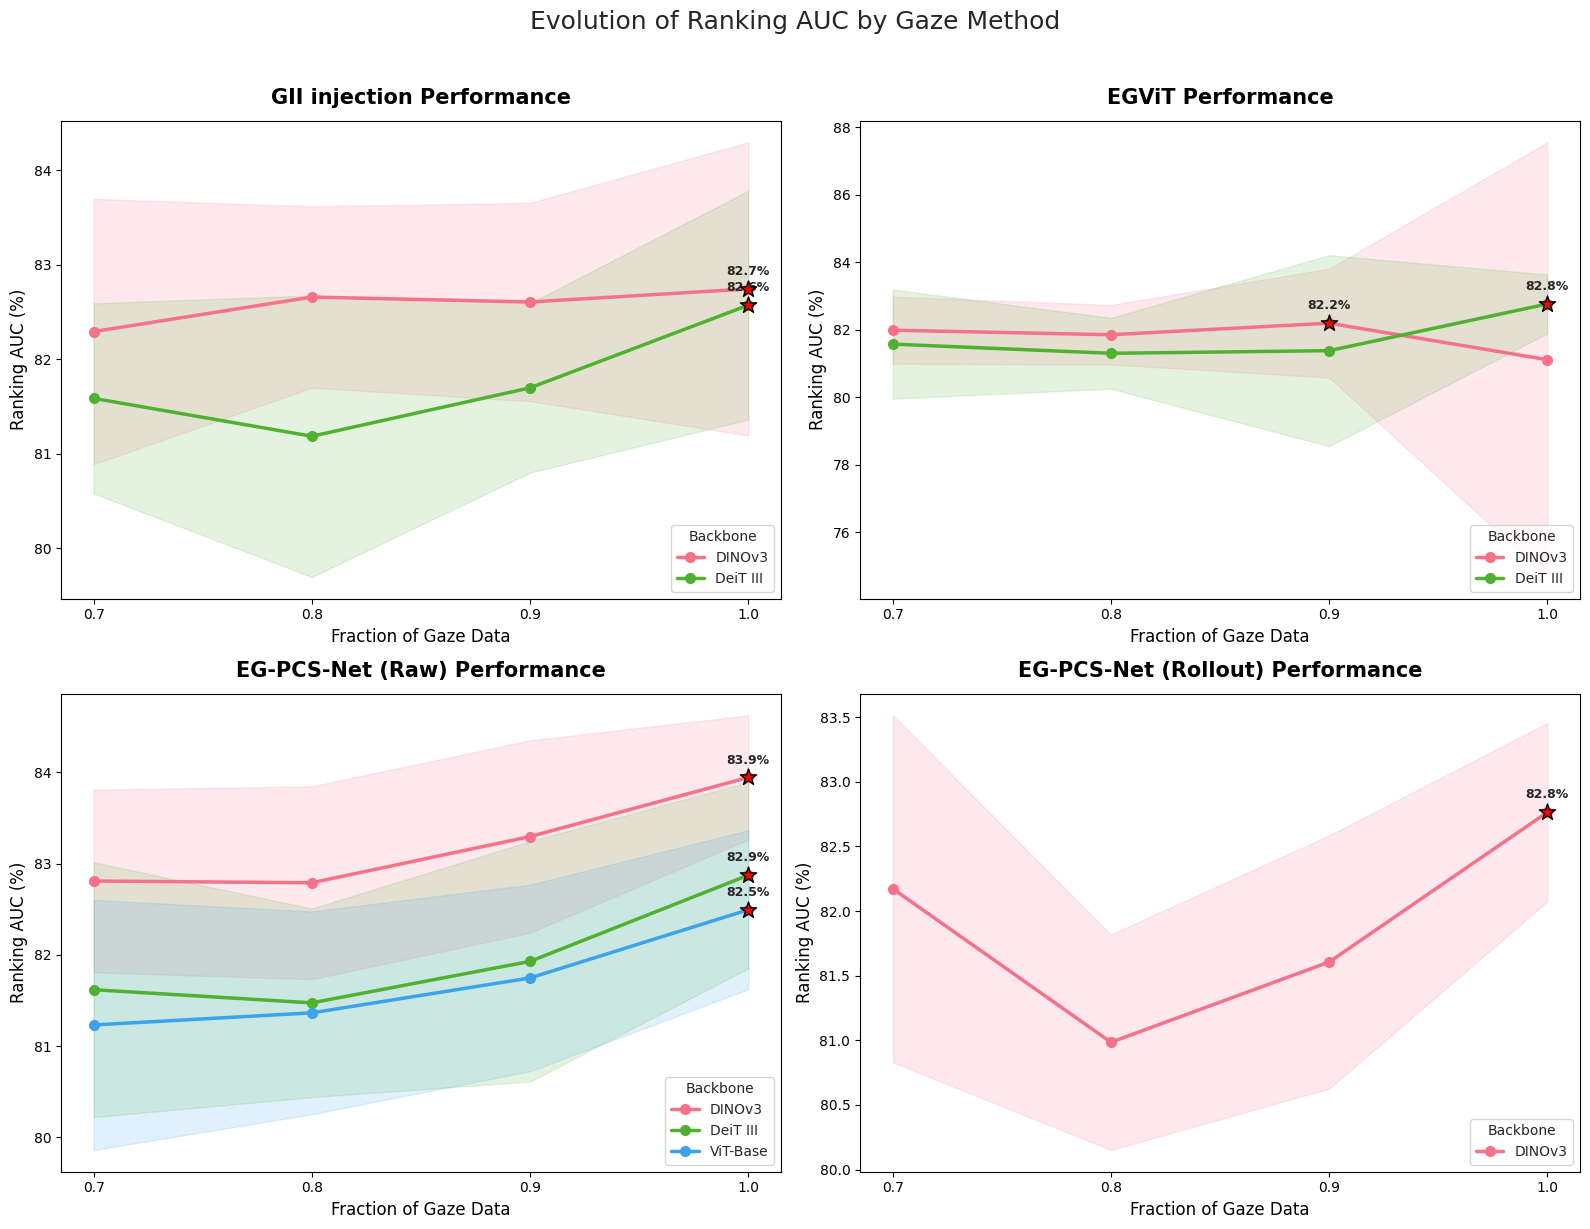

Plot saved successfully as 'images/gaze_frac_rank_auc_plot.png'!



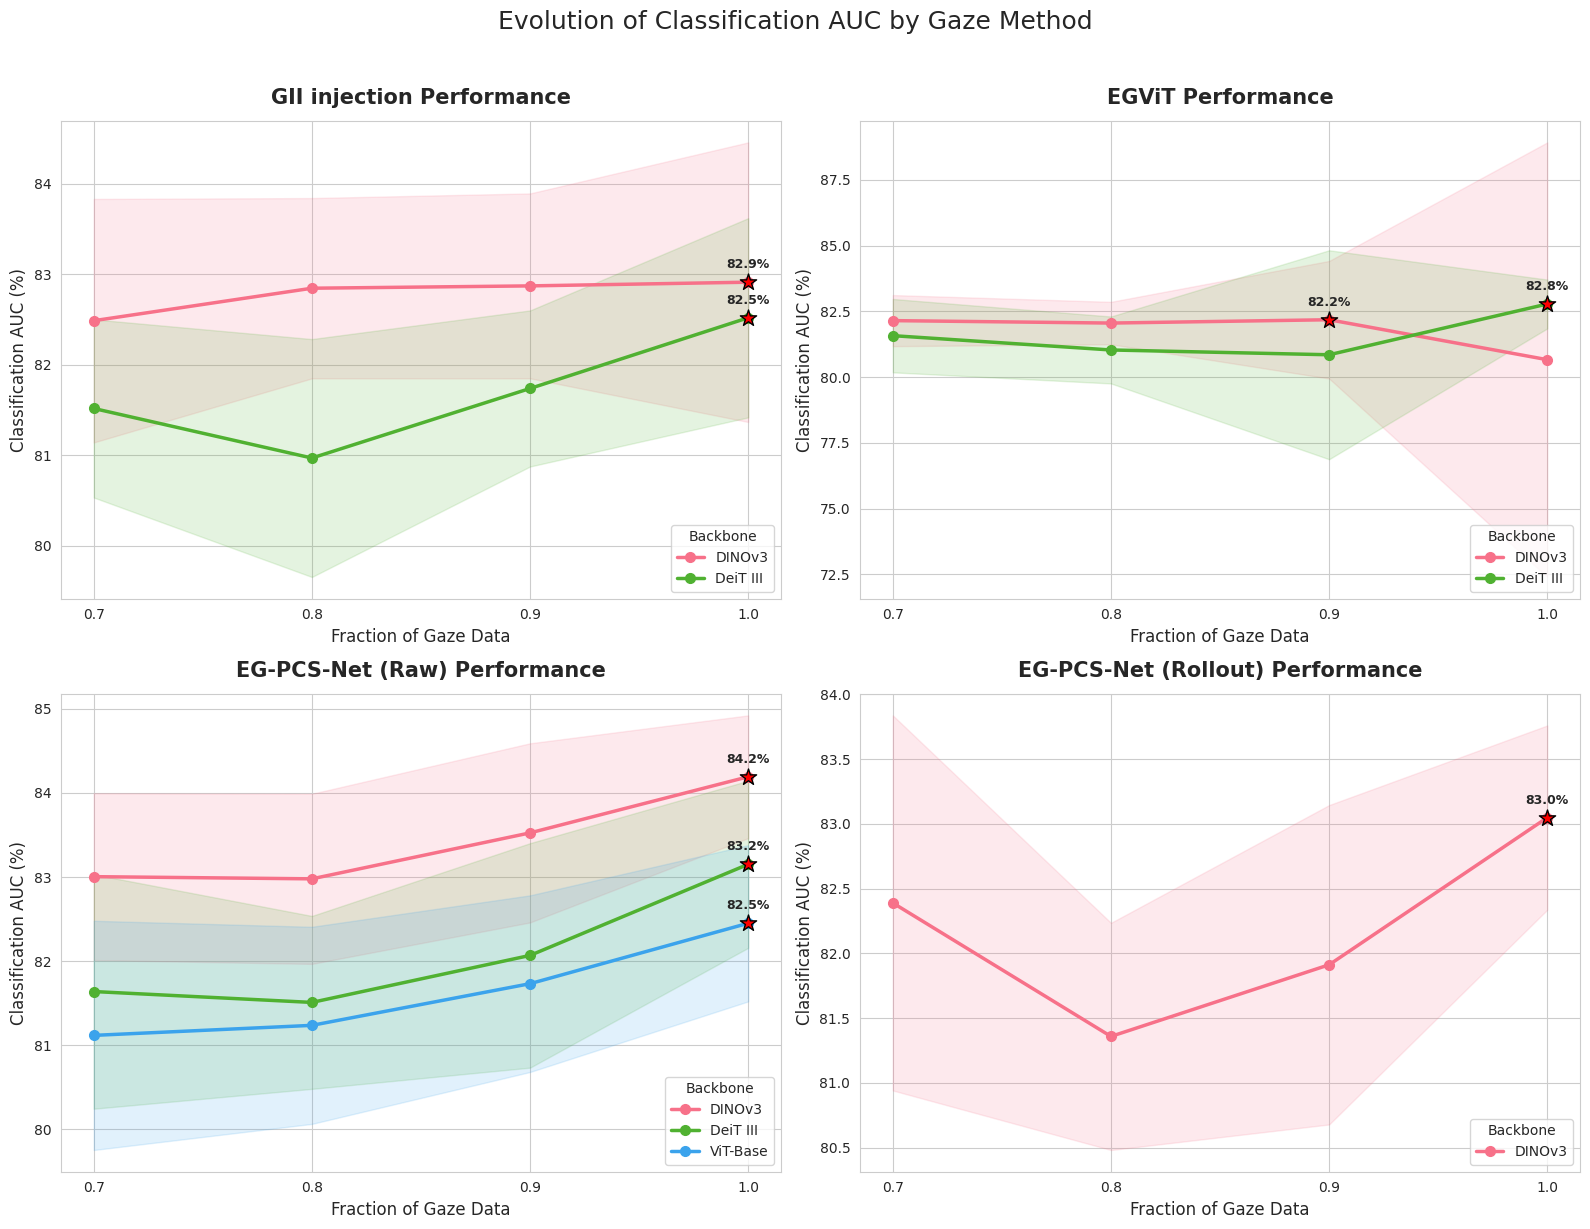

Plot saved successfully as 'images/gaze_frac_class_auc_plot.png'!



In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# ==========================================
# CONFIGURATION
# ==========================================
PLOT_MODE = "auc" # Options: "acc" or "auc"
# ==========================================

# 1. Load Data
try:
    df = pd.read_csv("gaze_modes_final.csv")
except FileNotFoundError:
    print("File 'gaze_modes_final.csv' not found. Please run Cell 1 first.")
    df = pd.DataFrame()

if not df.empty and 'train_gaze_frac' in df.columns:
    
    # 2. DYNAMIC SETUP: Find all valid fractions and methods directly from the data
    explicit_fractions = sorted(df['train_gaze_frac'].dropna().unique())
    print(f"Dynamically detected fractions: {explicit_fractions}")
    
    # Clean backbone names
    backbone_map = {
        'dinov3_vitb16': 'DINOv3',
        'vit_base_patch16_224': 'ViT-Base',
        'deit3_base_patch16_224': 'DeiT III',
        'vit_base_patch16_clip_224': 'CLIP',
        'clip': 'CLIP',
        'vit_small': 'ViT-Small'
    }
    df['backbone'] = df['backbone'].map(backbone_map).fillna(df['backbone'])
    
    # DYNAMIC METHODS: Extract directly from the CSV so no names ever mismatch
    target_methods = [m for m in df['gaze_method'].unique() if pd.notna(m) and m != 'Baseline']

    def generate_gaze_plots(metric_col, y_axis_label, filename_suffix):
        if metric_col not in df.columns:
            print(f"Skipping {y_axis_label} plot: '{metric_col}' not found.")
            return

        # 3. Aggregate: Calculate mean and std
        df_agg = df.groupby(['gaze_method', 'backbone', 'train_gaze_frac'], as_index=False).agg(
            mean_acc=(metric_col, 'mean'),
            std_acc=(metric_col, 'std')
        ).fillna({'std_acc': 0})

        # 4. Plotting Setup: Dynamically size the grid based on how many methods exist
        n_methods = len(target_methods)
        cols = 2
        rows = math.ceil(n_methods / cols)
        
        fig, axes = plt.subplots(rows, cols, figsize=(16, 6 * rows))
        if n_methods == 1: axes = [axes] # Handle single plot edge case
        else: axes = axes.flatten()
        sns.set_style("whitegrid")

        backbones = df_agg['backbone'].unique()
        colors = sns.color_palette("husl", len(backbones))
        color_dict = dict(zip(backbones, colors))

        # 5. Draw the plots
        for i, method in enumerate(target_methods):
            ax = axes[i]
            subset_method = df_agg[df_agg['gaze_method'] == method]

            if subset_method.empty:
                ax.set_title(f"{method}\n(No data found)", fontsize=14)
                continue

            for backbone in backbones:
                subset_bb = subset_method[subset_method['backbone'] == backbone].sort_values('train_gaze_frac')
                if subset_bb.empty or subset_bb['mean_acc'].isna().all():
                    continue

                # --- SMART PLOTTING: Handle single points vs. lines ---
                if len(subset_bb) == 1:
                    single_val = subset_bb['mean_acc'].iloc[0]
                    ax.axhline(y=single_val, color=color_dict[backbone], linestyle='--', linewidth=2, label=f"{backbone} (Baseline)")
                else:
                    ax.plot(subset_bb['train_gaze_frac'], subset_bb['mean_acc'], 
                            marker='o', label=backbone, color=color_dict[backbone], linewidth=2.5, markersize=7)
                    
                    ax.fill_between(
                        subset_bb['train_gaze_frac'], 
                        subset_bb['mean_acc'] - subset_bb['std_acc'], 
                        subset_bb['mean_acc'] + subset_bb['std_acc'], 
                        color=color_dict[backbone], alpha=0.15
                    )

                    # Highlight best fraction
                    best_idx = subset_bb['mean_acc'].idxmax()
                    best_row = subset_bb.loc[best_idx]
                    ax.scatter(best_row['train_gaze_frac'], best_row['mean_acc'], 
                               color='red', s=150, zorder=5, edgecolor='black', marker='*')
                    ax.annotate(f"{best_row['mean_acc']:.1f}%", 
                                (best_row['train_gaze_frac'], best_row['mean_acc']),
                                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9, weight='bold')

            ax.set_title(f"{method} Performance", fontsize=15, pad=12, weight='bold')
            ax.set_xlabel("Fraction of Gaze Data", fontsize=12)
            ax.set_ylabel(y_axis_label, fontsize=12)
            
            if len(explicit_fractions) > 1:
                ax.set_xticks(explicit_fractions)
                
            ax.legend(title="Backbone", fontsize=10, loc="lower right")

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        # Overall Title
        plt.suptitle(f"Evolution of {y_axis_label.replace(' (%)', '')} by Gaze Method", fontsize=18, y=1.02)
        plt.tight_layout()

        # 6. Save image
        os.makedirs("images", exist_ok=True)
        image_path = f"images/gaze_frac_{filename_suffix}_plot.png"
        plt.savefig(image_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Plot saved successfully as '{image_path}'!\n")

    # Determine which metrics to plot based on the config toggle
    if PLOT_MODE.lower() == "acc":
        print("Generating ACCURACY plots...")
        generate_gaze_plots(metric_col='test_rank_acc', y_axis_label='Ranking Accuracy (%)', filename_suffix='rank_acc')
        generate_gaze_plots(metric_col='test_class_acc', y_axis_label='Classification Accuracy (%)', filename_suffix='class_acc')
    elif PLOT_MODE.lower() == "auc":
        print("Generating AUC plots...")
        generate_gaze_plots(metric_col='test_rank_auc', y_axis_label='Ranking AUC (%)', filename_suffix='rank_auc')
        generate_gaze_plots(metric_col='test_class_auc', y_axis_label='Classification AUC (%)', filename_suffix='class_auc')
    else:
        print(f"Error: PLOT_MODE '{PLOT_MODE}' is invalid. Please use 'acc' or 'auc'.")

else:
    print("Could not plot. Make sure Cell 1 ran successfully and 'train_gaze_frac' is in the CSV.")

In [3]:
import pandas as pd
import numpy as np
from IPython.display import display

# ==========================================
# CONFIGURATION
# ==========================================
TABLE_MODE = "auc" # Options: "acc" or "auc"
# ==========================================

# 1. Load Data
try:
    df = pd.read_csv("gaze_modes_final.csv")
except FileNotFoundError:
    print("File 'gaze_modes_final.csv' not found. Please run Cell 1 first.")
    df = pd.DataFrame()

if not df.empty:
    # Set dynamic columns based on toggle
    if TABLE_MODE.lower() == "acc":
        sort_col, class_col = 'test_rank_acc', 'test_class_acc'
        metric_name = "Accuracy"
    elif TABLE_MODE.lower() == "auc":
        sort_col, class_col = 'test_rank_auc', 'test_class_auc'
        metric_name = "AUC"
    else:
        raise ValueError("TABLE_MODE must be 'acc' or 'auc'")

    if sort_col not in df.columns:
        print(f"Error: Column '{sort_col}' not found. Make sure Cell 1 ran successfully.")
    else:
        # 2. Clean backbone names dynamically
        backbone_map = {
            'dinov3_vitb16': 'DINOv3',
            'vit_base_patch16_224': 'ViT-Base',
            'deit3_base_patch16_224': 'DeiT III',
            'vit_base_patch16_clip_224': 'CLIP',
            'clip': 'CLIP',
            'vit_small': 'ViT-Small'
        }
        df['backbone'] = df['backbone'].map(backbone_map).fillna(df['backbone'])
        df['gaze_method'] = df['gaze_method'].str.replace('Align', 'EG-PCS-Net')

        # 3. Aggregate: Find the SINGLE best run based on the primary metric (Rank)
        df_sorted = df.sort_values(by=sort_col, ascending=False)
        df_top1 = df_sorted.drop_duplicates(subset=['gaze_method', 'backbone'], keep='first')

        # 4. Create Pivot Tables for formatting
        pivot_rank_max = df_top1.pivot_table(index='gaze_method', columns='backbone', values=sort_col, aggfunc='first')
        pivot_class_max = df_top1.pivot_table(index='gaze_method', columns='backbone', values=class_col, aggfunc='first')
        pivot_runs = df_top1.pivot_table(index='gaze_method', columns='backbone', values='run_name', aggfunc='first')

        existing_methods = df_top1['gaze_method'].unique()
        ideal_cols = ['DINOv3', 'DeiT III', 'CLIP', 'ViT-Base']
        cols = [c for c in ideal_cols if c in pivot_rank_max.columns]
        if not cols: cols = list(pivot_rank_max.columns)

        # ==========================================================
        # PART A: LATEX TABLE GENERATION
        # ==========================================================
        latex_str = []
        latex_str.append("\\begin{table*}[ht]")
        latex_str.append("\\centering")
        latex_str.append(f"\\caption{{Best Seed {metric_name} (Rank / Class) across all evaluated runs.}}")
        latex_str.append(f"\\label{{tab:gaze_modes_best_{TABLE_MODE}}}")
        latex_str.append("\\begin{tabular}{l" + "c"*len(cols) + "}")
        latex_str.append("\\toprule")
        latex_str.append(f"Method & {' & '.join(cols)} \\\\")
        latex_str.append("\\midrule")
        
        for method in existing_methods:
            row_values = []
            for col in cols:
                val_r_max = pivot_rank_max.loc[method, col] if method in pivot_rank_max.index and col in pivot_rank_max.columns else np.nan
                val_c_max = pivot_class_max.loc[method, col] if method in pivot_class_max.index and col in pivot_class_max.columns else np.nan
                
                if np.isnan(val_r_max) or np.isnan(val_c_max):
                    row_values.append("-")
                else:
                    s_r_max_str = f"{val_r_max:.2f}"
                    s_c_max_str = f"{val_c_max:.2f}"
                    
                    col_max_r_best = pivot_rank_max[col].max()
                    col_max_c_best = pivot_class_max[col].max()
                    
                    if abs(val_r_max - col_max_r_best) < 1e-9: s_r_max_str = f"\\textbf{{{s_r_max_str}}}"
                    if abs(val_c_max - col_max_c_best) < 1e-9: s_c_max_str = f"\\textbf{{{s_c_max_str}}}"
                    
                    final_str = f"{s_r_max_str}/{s_c_max_str}"
                    row_values.append(final_str)
                    
            clean_method = method.replace("GII injection", "GII injection \\cite{Chen2026GIIViT}")
            clean_method = clean_method.replace("EGViT", "EGViT \\cite{Ma2023EGViT}")
            latex_str.append(f"{clean_method} & {' & '.join(row_values)} \\\\")

        latex_str.append("\\bottomrule")
        latex_str.append("\\end{tabular}")
        latex_str.append("\\end{table*}")

        print("% " + "="*50)
        print(f"% LATEX TABLE: TOP-1 {metric_name.upper()} (Copy to Overleaf)")
        print("% " + "="*50)
        print("\n".join(latex_str))
        print("\n")

        # ==========================================================
        # PART B: PANDAS NOTEBOOK DISPLAY (METRIC)
        # ==========================================================
        display_df = pd.DataFrame(index=existing_methods, columns=cols)
        display_df.index.name = "Method"
        
        for method in existing_methods:
            for col in cols:
                val_r_max = pivot_rank_max.loc[method, col] if method in pivot_rank_max.index and col in pivot_rank_max.columns else np.nan
                val_c_max = pivot_class_max.loc[method, col] if method in pivot_class_max.index and col in pivot_class_max.columns else np.nan
                
                if np.isnan(val_r_max) or np.isnan(val_c_max):
                    display_df.loc[method, col] = "-"
                else:
                    display_df.loc[method, col] = f"{val_r_max:.2f}% / {val_c_max:.2f}%"

        print("# " + "="*50)
        print(f"# NOTEBOOK DISPLAY: TOP-1 {metric_name.upper()} (Rank / Class)")
        print("# " + "="*50)
        display(display_df)
        print("\n")

        # ==========================================================
        # PART C: PANDAS NOTEBOOK DISPLAY (RUN IDs)
        # ==========================================================
        run_id_df = pd.DataFrame(index=existing_methods, columns=cols)
        run_id_df.index.name = "Method"

        for method in existing_methods:
            for col in cols:
                if method in pivot_runs.index and col in pivot_runs.columns:
                    run_id = pivot_runs.loc[method, col]
                    run_id_df.loc[method, col] = run_id if pd.notna(run_id) else "-"
                else:
                    run_id_df.loc[method, col] = "-"

        print("# " + "="*50)
        print(f"# EXACT WANDB RUN IDs FOR THE TOP-1 SEEDS ({metric_name.upper()})")
        print("# " + "="*50)
        display(run_id_df)
else:
    print("Dataframe is empty. Please check your CSV.")

% ==================================================
% LATEX TABLE: TOP-1 AUC (Copy to Overleaf)
% ==================================================
\begin{table*}[ht]
\centering
\caption{Best Seed AUC (Rank / Class) across all evaluated runs.}
\label{tab:gaze_modes_best_auc}
\begin{tabular}{lccc}
\toprule
Method & DINOv3 & DeiT III & ViT-Base \\
\midrule
EG-PCS-Net (Raw) & \textbf{85.41}/\textbf{85.58} & 84.46/\textbf{84.49} & \textbf{83.84}/\textbf{83.78} \\
EGViT \cite{Ma2023EGViT} & 85.13/85.30 & 83.92/84.11 & - \\
GII injection \cite{Chen2026GIIViT} & 84.27/84.25 & \textbf{84.64}/84.28 & - \\
EG-PCS-Net (Rollout) & 84.10/84.45 & - & - \\
\bottomrule
\end{tabular}
\end{table*}


# ==================================================
# NOTEBOOK DISPLAY: TOP-1 AUC (Rank / Class)
# ==================================================


,DINOv3,DeiT III,ViT-Base
Method,,,
EG-PCS-Net (Raw),85.41% / 85.58%,84.46% / 84.49%,83.84% / 83.78%
EGViT,85.13% / 85.30%,83.92% / 84.11%,-
GII injection,84.27% / 84.25%,84.64% / 84.28%,-
EG-PCS-Net (Rollout),84.10% / 84.45%,-,-




# ==================================================
# EXACT WANDB RUN IDs FOR THE TOP-1 SEEDS (AUC)
# ==================================================


,DINOv3,DeiT III,ViT-Base
Method,,,
EG-PCS-Net (Raw),hearty-sweep-8,bright-sweep-48,lucky-sweep-97
EGViT,eager-sweep-48,worthy-sweep-124,-
GII injection,lilac-sweep-6,wandering-sweep-84,-
EG-PCS-Net (Rollout),glorious-sweep-17,-,-


In [4]:
import pandas as pd
import numpy as np
from IPython.display import display

# ==========================================
# CONFIGURATION
# ==========================================
TABLE_MODE = "auc" # Options: "acc" or "auc"
# ==========================================

# 1. Load Data
try:
    df = pd.read_csv("gaze_modes_final.csv")
except FileNotFoundError:
    print("File 'gaze_modes_final.csv' not found. Please run Cell 1 first.")
    df = pd.DataFrame()

if not df.empty:
    if TABLE_MODE.lower() == "acc":
        sort_col, class_col = 'test_rank_acc', 'test_class_acc'
        metric_name = "Accuracy"
    elif TABLE_MODE.lower() == "auc":
        sort_col, class_col = 'test_rank_auc', 'test_class_auc'
        metric_name = "AUC"
    else:
        raise ValueError("TABLE_MODE must be 'acc' or 'auc'")

    if sort_col not in df.columns:
        print(f"Error: Column '{sort_col}' not found. Make sure Cell 1 ran successfully.")
    else:
        # 2. Dynamic Cleaning
        backbone_map = {
            'dinov3_vitb16': 'DINOv3',
            'vit_base_patch16_224': 'ViT-Base',
            'deit3_base_patch16_224': 'DeiT III',
            'vit_base_patch16_clip_224': 'CLIP',
            'clip': 'CLIP',
            'vit_small': 'ViT-Small'
        }
        df['backbone'] = df['backbone'].map(backbone_map).fillna(df['backbone'])
        df['gaze_method'] = df['gaze_method'].str.replace('Align', 'EG-PCS-Net')

        # 3. Aggregate: Find the SINGLE best run per Method + Fraction + Backbone
        df_sorted = df.sort_values(by=sort_col, ascending=False)
        df_top1 = df_sorted.drop_duplicates(subset=['gaze_method', 'train_gaze_frac', 'backbone'], keep='first')

        # 4. Create Multi-Index Pivot Tables
        pivot_rank_top1 = df_top1.pivot_table(index=['gaze_method', 'train_gaze_frac'], columns='backbone', values=sort_col, aggfunc='first')
        pivot_class_top1 = df_top1.pivot_table(index=['gaze_method', 'train_gaze_frac'], columns='backbone', values=class_col, aggfunc='first')

        methods = df_top1['gaze_method'].unique()
        fractions = sorted(df_top1['train_gaze_frac'].unique())
        ideal_cols = ['DINOv3', 'DeiT III', 'CLIP', 'ViT-Base']
        cols = [c for c in ideal_cols if c in pivot_rank_top1.columns]
        if not cols: cols = list(pivot_rank_top1.columns)

        # ==========================================================
        # PART A: LATEX TABLE (Multi-Row by Fraction)
        # ==========================================================
        latex_str = []
        latex_str.append("\\begin{table*}[ht]")
        latex_str.append("\\centering")
        latex_str.append(f"\\caption{{Top-1 {metric_name} (Best Seed) across different Gaze Fractions.}}")
        latex_str.append(f"\\label{{tab:top1_gaze_frac_{TABLE_MODE}}}")
        latex_str.append("\\begin{tabular}{ll" + "c"*len(cols) + "}")
        latex_str.append("\\toprule")
        latex_str.append(f"Method & Frac. & {' & '.join(cols)} \\\\")
        latex_str.append("\\midrule")

        for method in methods:
            method_label_shown = False
            for frac in fractions:
                if (method, frac) not in pivot_rank_top1.index:
                    continue
                    
                row_values = []
                for col in cols:
                    val_r = pivot_rank_top1.loc[(method, frac), col] if col in pivot_rank_top1.columns else np.nan
                    val_c = pivot_class_top1.loc[(method, frac), col] if col in pivot_class_top1.columns else np.nan

                    if np.isnan(val_r) or np.isnan(val_c):
                        row_values.append("-")
                    else:
                        is_bold_r = abs(val_r - pivot_rank_top1[col].max()) < 1e-9
                        is_bold_c = abs(val_c - pivot_class_top1[col].max()) < 1e-9
                        
                        r_str = f"\\textbf{{{val_r:.2f}}}" if is_bold_r else f"{val_r:.2f}"
                        c_str = f"\\textbf{{{val_c:.2f}}}" if is_bold_c else f"{val_c:.2f}"
                        row_values.append(f"{r_str}/{c_str}")

                display_m = method if not method_label_shown else ""
                display_m = display_m.replace("GII injection", "GII injection \\cite{Chen2026GIIViT}").replace("EGViT", "EGViT \\cite{Ma2023EGViT}")
                
                latex_str.append(f"{display_m} & {frac} & {' & '.join(row_values)} \\\\")
                method_label_shown = True
            latex_str.append("\\hline")

        latex_str.append("\\bottomrule")
        latex_str.append("\\end{tabular}")
        latex_str.append("\\end{table*}")

        print("% " + "="*50)
        print(f"% LATEX: TOP-1 {metric_name.upper()} BY FRACTION")
        print("% " + "="*50)
        print("\n".join(latex_str))

        # ==========================================================
        # PART B: PANDAS DISPLAY
        # ==========================================================
        print("\n# " + "="*50)
        print(f"# NOTEBOOK DISPLAY: TOP-1 BY FRACTION ({metric_name.upper()})")
        print("# " + "="*50)
        
        display_df = pivot_rank_top1[cols].copy()
        for col in cols:
            display_df[col] = pivot_rank_top1[col].map('{:.2f}'.format) + "% / " + pivot_class_top1[col].map('{:.2f}'.format) + "%"
        
        display(display_df.replace("nan% / nan%", "-"))
else:
    print("No data found in gaze_modes_final.csv")

% ==================================================
% LATEX: TOP-1 AUC BY FRACTION
% ==================================================
\begin{table*}[ht]
\centering
\caption{Top-1 AUC (Best Seed) across different Gaze Fractions.}
\label{tab:top1_gaze_frac_auc}
\begin{tabular}{llccc}
\toprule
Method & Frac. & DINOv3 & DeiT III & ViT-Base \\
\midrule
EG-PCS-Net (Raw) & 0.7 & 84.27/84.42 & 83.82/83.95 & \textbf{83.84}/83.78 \\
 & 0.8 & 84.05/84.10 & 83.35/83.32 & 83.03/82.92 \\
 & 0.9 & 84.92/84.99 & 83.78/83.87 & 83.38/83.46 \\
 & 1.0 & \textbf{85.41}/\textbf{85.58} & 84.46/\textbf{84.49} & 83.78/\textbf{83.87} \\
\hline
EGViT \cite{Ma2023EGViT} & 0.7 & 83.69/83.84 & 83.88/83.79 & - \\
 & 0.8 & 82.88/82.85 & 83.24/83.23 & - \\
 & 0.9 & 84.19/84.02 & 83.55/83.73 & - \\
 & 1.0 & 85.13/85.30 & 83.92/84.11 & - \\
\hline
GII injection \cite{Chen2026GIIViT} & 0.7 & 84.23/84.44 & 83.31/83.37 & - \\
 & 0.8 & 84.27/84.25 & 83.43/83.01 & - \\
 & 0.9 & 83.86/84.18 & 83.47/83.56 & - \\
 & 1.0 & 84

backbone                                       DINOv3         DeiT III  \
gaze_method          train_gaze_frac                                     
EG-PCS-Net (Raw)     0.7              84.27% / 84.42%  83.82% / 83.95%   
                     0.8              84.05% / 84.10%  83.35% / 83.32%   
                     0.9              84.92% / 84.99%  83.78% / 83.87%   
                     1.0              85.41% / 85.58%  84.46% / 84.49%   
EG-PCS-Net (Rollout) 0.7              84.10% / 84.45%                -   
                     0.8              81.91% / 82.36%                -   
                     0.9              82.78% / 83.46%                -   
                     1.0              83.63% / 83.97%                -   
EGViT                0.7              83.69% / 83.84%  83.88% / 83.79%   
                     0.8              82.88% / 82.85%  83.24% / 83.23%   
                     0.9              84.19% / 84.02%  83.55% / 83.73%   
                     1.0              85.13% / 85.30%  83.92% / 84.11%   
GII injection        0.7              84.23% / 84.44%  83.31% / 83.37%   
                     0.8              84.27% / 84.25%  83.43% / 83.01%   
                     0.9              83.86% / 84.18%  83.47% / 83.56%   
                     1.0              84.08% / 84.31%  84.64% / 84.28%   

backbone                                     ViT-Base  
gaze_method          train_gaze_frac                   
EG-PCS-Net (Raw)     0.7              83.84% / 83.78%  
                     0.8              83.03% / 82.92%  
                     0.9              83.38% / 83.46%  
                     1.0              83.78% / 83.87%  
EG-PCS-Net (Rollout) 0.7                            -  
                     0.8                            -  
                     0.9                            -  
                     1.0                            -  
EGViT                0.7                            -  
                     0.8                            -  
                     0.9                            -  
                     1.0                            -  
GII injection        0.7                            -  
                     0.8                            -  
                     0.9                            -  
                     1.0                            -